# Fine-tuning DTrOCR on IAM dataset
This is an example of fine-tuning DTrOCR on IAM dataset handwritten words from [Kaggle](https://www.kaggle.com/datasets/teykaicong/iamondb-handwriting-dataset). IAM Aachen splits can be downloaded [here](https://www.openslr.org/56/).

# Dataset folder structure
```
data/
│
├── images/                              # PNG files
│   ├── 0.png                           
│   │   .
│   │   .
│   │   .
│   └── 1.png                          
│
└── labels/                                # txt files
	├── 0.txt
	.
	.
	.
	└── 1.txt
```

In [1]:
from pathlib import Path

MODEL='Test'

EPOCHS=1

LR=1e-4

DATA_PATH = Path('data/kanjivg')

DATASET_PATH = Path('preprocessed_data/kanjivg')

DATA_PATH.mkdir(parents=True, exist_ok=True)

DATASET_PATH.mkdir(parents=True, exist_ok=True)

PREPROCESS_DATA = False

AUGMENT_DATA = False

# Build lists of images and texts

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
if PREPROCESS_DATA:
    DATA_PATH.mkdir(parents=True, exist_ok=True)
    shutil.unpack_archive('../kanjivg/kanjivg-20240807-all.zip', DATA_PATH)

In [3]:
import os
if PREPROCESS_DATA:
    vocab = set()
    with open('google_sp.vocab', 'r') as f:
        for line in f.readlines():
            vocab.add(line[0])
            
    vocab = list(vocab)
    print(vocab[100:120])
    print(len(vocab))
    def remove_stroke_order_graphic(file):
        with open(file, 'r') as f:
            text = f.read()
            idx = text.rfind('<g')
            removed_stroke_order_xml = text.replace(text[idx:-7], '')

        with open(file, 'w') as f:
            f.write(removed_stroke_order_xml)
        
    filenames = os.listdir(DATA_PATH / 'kanji')
    print(filenames[0])
    for file in filenames:
        path = os.path.join(DATA_PATH / 'kanji', file)
        if os.path.isdir(path): continue
        remove_stroke_order_graphic(str(DATA_PATH / 'kanji' / file))

In [4]:
import xml.etree.ElementTree as ET
from cairosvg import svg2png
import os
import shutil
if PREPROCESS_DATA or AUGMENT_DATA:
    if DATASET_PATH.exists():
        shutil.rmtree(DATASET_PATH)
    DATASET_PATH.mkdir(parents=True, exist_ok=True)
    
    def create_png(svg):
        with open(svg, 'r') as f:
            xml = f.read()
        root = ET.fromstring(xml)
        kanji_char = root[0][0].attrib['{http://kanjivg.tagaini.net}element']
        if kanji_char in vocab:
            new_filepath = str(DATASET_PATH / (kanji_char + '.png'))
            svg2png(url=svg, write_to=new_filepath, background_color='white')
            return new_filepath, kanji_char
        else:
            return False, False
    
    data_dict = {}
    for kanji in os.listdir(DATA_PATH / 'kanji'):
        path = os.path.join(DATA_PATH / 'kanji', kanji)
        if os.path.isdir(path): continue
        new_filepath, kanji_char = create_png(str(DATA_PATH / 'kanji' / kanji))
        if new_filepath != False:
            data_dict[new_filepath] = kanji_char
        
    print(list(data_dict.items())[0])

In [5]:
import json
from util.augmentation import augment_dataset
from util.data_processing import save_labels, split_dataset

if PREPROCESS_DATA:
    save_labels(data_dict, DATASET_PATH / 'labels.json')
    split_dataset(DATASET_PATH)

with open(str(DATASET_PATH / 'train_labels.json'), 'r') as fp:
    data_dict = json.load(fp)
        
if AUGMENT_DATA:
    augment_dataset(data_dict, 3, 3, 5)
    save_labels(data_dict, DATASET_PATH / 'augmented_labels.json')

/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import json
from pathlib import Path

with open(str(DATASET_PATH / 'train_labels.json'), 'r') as fp:
    data_dict = json.load(fp)

print(f"{len(data_dict.items())} dict elements")

words_files = list(data_dict.items())
print(words_files[0])

3290 dict elements
('preprocessed_data/kanjivg/瑛.png', '瑛')


In [7]:
from util.data_processing import get_words_list

with open(str(DATASET_PATH / 'test_labels.json'), 'r') as fp:
    test_dict = json.load(fp)
    
test_words_files = list(test_dict.items())
train_word_records = get_words_list(test_words_files)
test_word_records = get_words_list(words_files)
print(f'Train size: {len(train_word_records)}; Test size: {len(test_word_records)}')

Building dataset: 100%|██████████| 366/366 [00:00<00:00, 4266.95it/s]

Word(file_path='preprocessed_data/kanjivg/總.png', transcription='總')



Building dataset: 100%|██████████| 3290/3290 [00:00<00:00, 4205.14it/s]

Word(file_path='preprocessed_data/kanjivg/瑛.png', transcription='瑛')
Train size: 366; Test size: 3290


# Build dataset and dataloader

In [8]:
from util.data_processing import WORDSDataset
from dtrocr.config import DTrOCRConfig

config = DTrOCRConfig(
    # attn_implementation='flash_attention_2'
)
train_data = WORDSDataset(words=train_word_records, config=config)
test_data = WORDSDataset(words=test_word_records, config=config)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [9]:
from torch.utils.data import DataLoader
import multiprocessing as mp

train_dataloader = DataLoader(train_data, batch_size=8, shuffle=True, num_workers=mp.cpu_count())
test_dataloader = DataLoader(test_data, batch_size=8, shuffle=False, num_workers=mp.cpu_count())

# Model

In [10]:
from util.model import get_model

model = get_model(config, MODEL)

# Training

In [11]:
from util.model import train

train(model, train_dataloader, test_dataloader, EPOCHS, MODEL, LR, 'Kanjivg')

Evaluating test set: 100%|██████████| 412/412 [00:37<00:00, 11.09it/s]

Epoch: 1 - Train loss: 3.7688594797383184, Train accuracy: 0.5066252635872882, Test loss: 5.983039938130425, Test accuracy: 0.5061141980215184


# Test

In [12]:
from dtrocr.model import DTrOCRLMHeadModel
from dtrocr.config import DTrOCRConfig
from dtrocr.processor import DTrOCRProcessor
import torch
torch.save(model.state_dict(), f'../models/{MODEL}.pt')
# model = DTrOCRLMHeadModel(DTrOCRConfig())
model.eval()
model.to('cpu')
test_processor = DTrOCRProcessor(DTrOCRConfig())

/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Ответ:  總  Вывод модели:  


/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/dtrocr-0.3.0-py3.12.egg/dtrocr/model.py:295: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  next_tokens = torch.argmax(torch.nn.functional.softmax(next_token_scores), dim=-1)


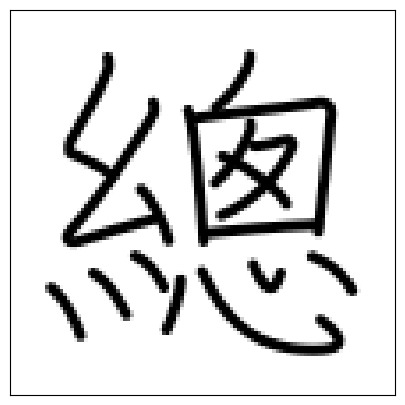

Ответ:  傭  Вывод модели:  


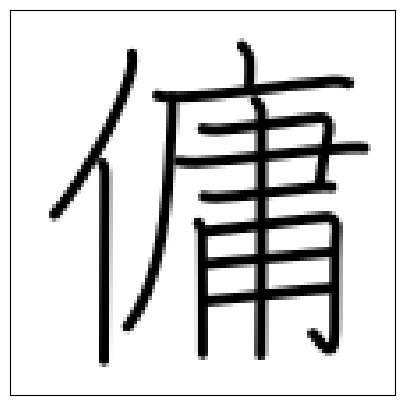

Ответ:  瞼  Вывод модели:  


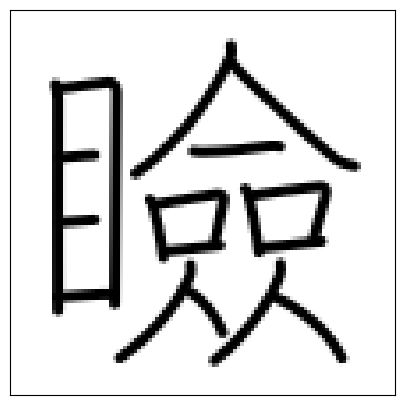

Ответ:  謁  Вывод модели:  


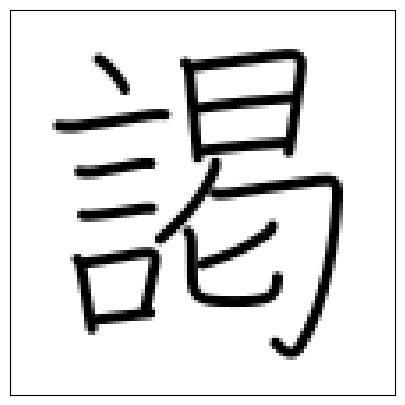

Ответ:  氣  Вывод модели:  


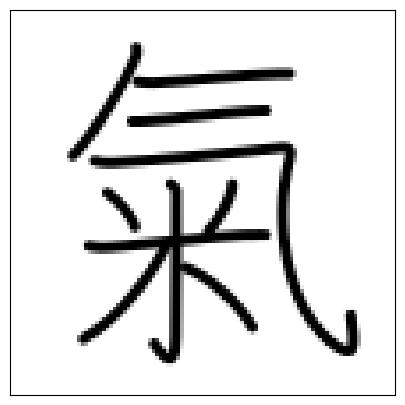

Ответ:  机  Вывод модели:  


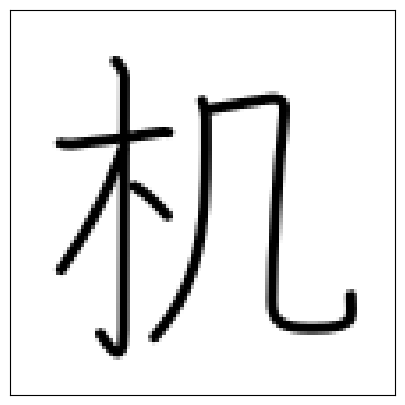

Ответ:  唆  Вывод модели:  


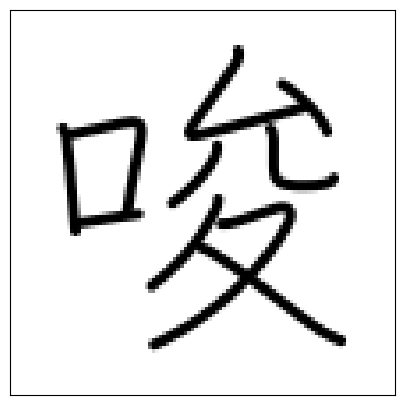

Ответ:  萎  Вывод модели:  


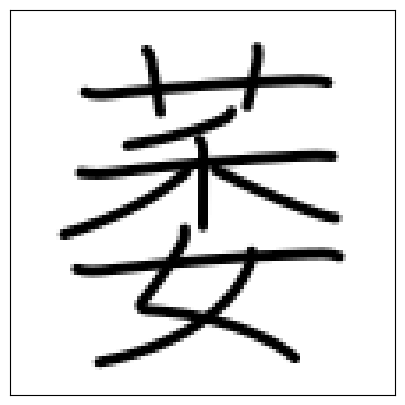

Ответ:  透  Вывод модели:  


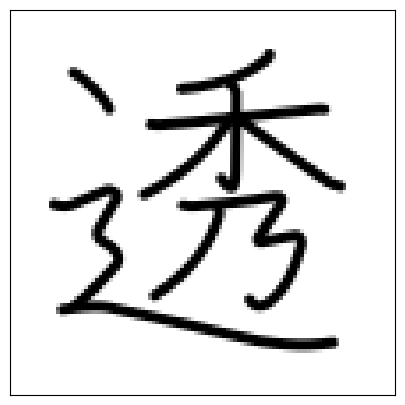

Ответ:  植  Вывод модели:  


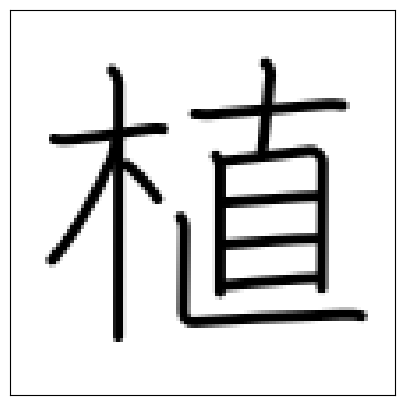

In [13]:
from util.model import test

test(model, train_word_records, 10)